# Bayesian model averaging probability heat map

Run the final cell to fit and plot every supported 2D dataset.

In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="A worker stopped while some jobs were given to the executor.*",
    category=UserWarning,
)

project_root = Path.cwd()
if not (project_root / "bayesian_model_averaging").is_dir() and (project_root.parent / "bayesian_model_averaging").is_dir():
    project_root = project_root.parent
if (project_root / "bayesian_model_averaging").is_dir():
    sys.path.insert(0, str(project_root))

from bayesian_model_averaging.experiments.classification_2d import (
    format_convergence_history,
    plot_probability_heatmap,
    run_2d_classification_experiment,
)
from IPython.display import display

In [2]:
DATASETS = (
    "moon",
    "iris",
    "gaussian",
    "blobs",
    "circles",
    "xor",
    "spirals",
    "anisotropic_blobs",
    "checkerboard",
    "classification",
)
BLOB_CENTER_RADIUS = 3.0
BLOB_CLUSTER_STANDARD_DEVIATION = 1.5

DATA_PARAMETERS = {
    "n_samples": 2400,
    "noise": 0.24,
    "random_state": 71,
    "feature_indices": (0, 1),
    "mean_distance": 3.0,
    "standard_deviation": 1.0,
    "n_classes": 4,
    "blob_center_radius": BLOB_CENTER_RADIUS,
    "blob_cluster_standard_deviation": BLOB_CLUSTER_STANDARD_DEVIATION,
    "circle_factor": 0.5,
    "spiral_turns": 2,
    "spiral_noise": 0.05,
    "checkerboard_cells": 4,
    "checkerboard_extent": 4.0,
    "checkerboard_label_noise": 0.0,
    "anisotropy": 3.0,
    "rotation": 0.35,
    "classification_class_sep": 1.0,
    "classification_flip_y": 0.05,
}

SPLIT_PARAMETERS = {
    "test_size": 0.30,
    "split_random_state": 7,
}

MODEL_PARAMETERS = {
    "representation": "identity",
    "temperature": 0.25,
    "n_estimators": "auto",
    "max_estimators": 500,
    "tolerance": 0.001,
    "convergence_metric": "median",
    "convergence_size": 256,
    "cv": 5,
    "max_neighbors": None,
    "weights": "distance",
    "n_jobs": -1,
    "random_state": 12,
}

PLOT_PARAMETERS = {
    "padding": 0.55,
    "grid_size": 150,
    "class_label": None,
    "output_path": None,
}

dataset: moon
test accuracy: 0.933
estimators used: 500
converged: False
20 estimators: initial ensemble
40 estimators: median probability change = 0.009237
80 estimators: median probability change = 0.003889
160 estimators: median probability change = 0.003191
320 estimators: median probability change = 0.002568
500 estimators: median probability change = 0.001775


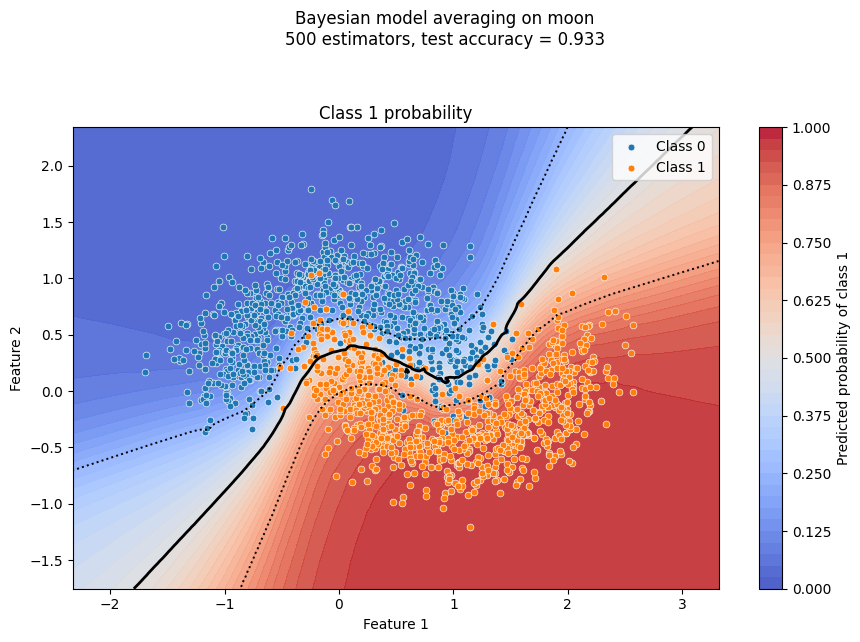

dataset: iris
test accuracy: 0.756
estimators used: 500
converged: False
20 estimators: initial ensemble
40 estimators: median probability change = 0.006906
80 estimators: median probability change = 0.008476
160 estimators: median probability change = 0.005457
320 estimators: median probability change = 0.003453
500 estimators: median probability change = 0.002815


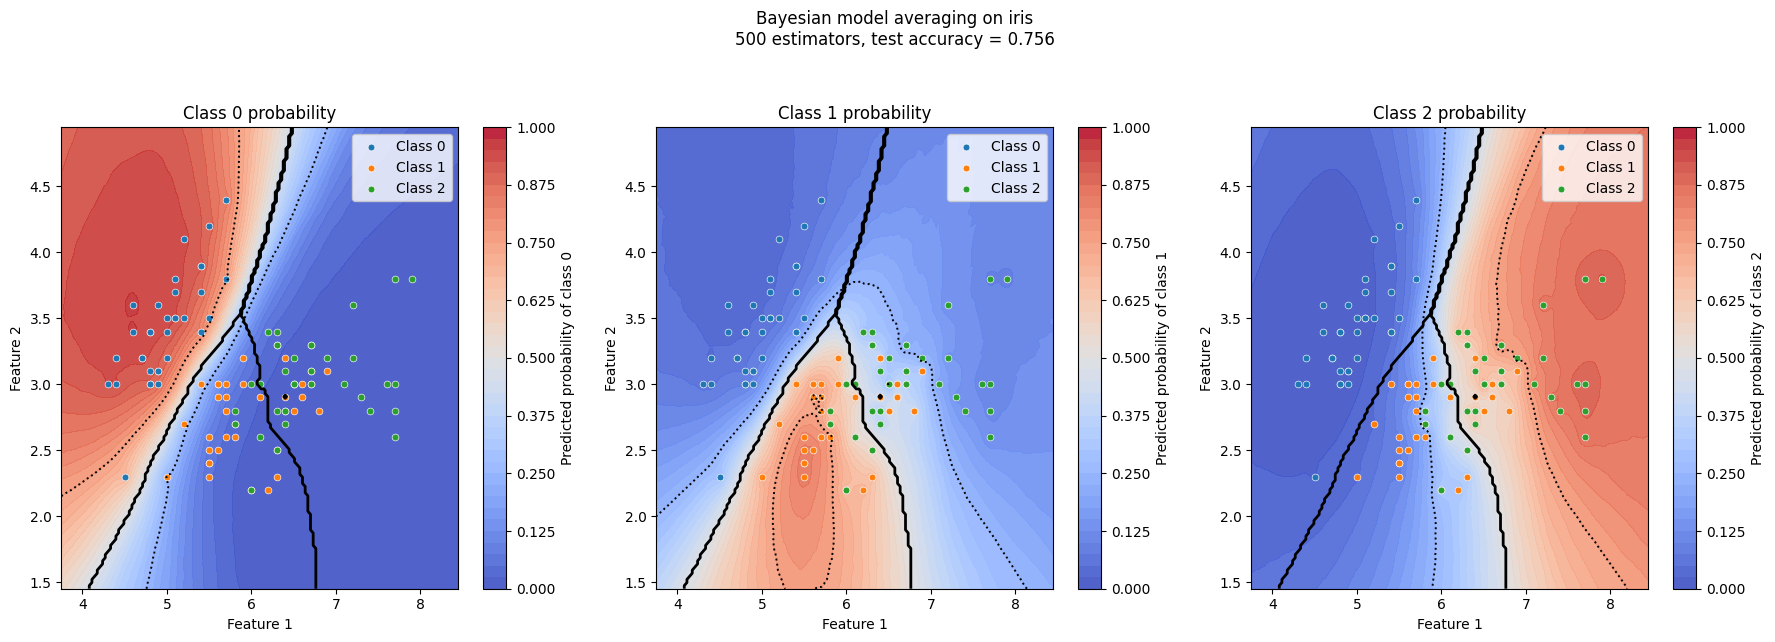

dataset: gaussian
test accuracy: 0.935
estimators used: 320
converged: True
20 estimators: initial ensemble
40 estimators: median probability change = 0.005240
80 estimators: median probability change = 0.002708
160 estimators: median probability change = 0.001838
320 estimators: median probability change = 0.000946


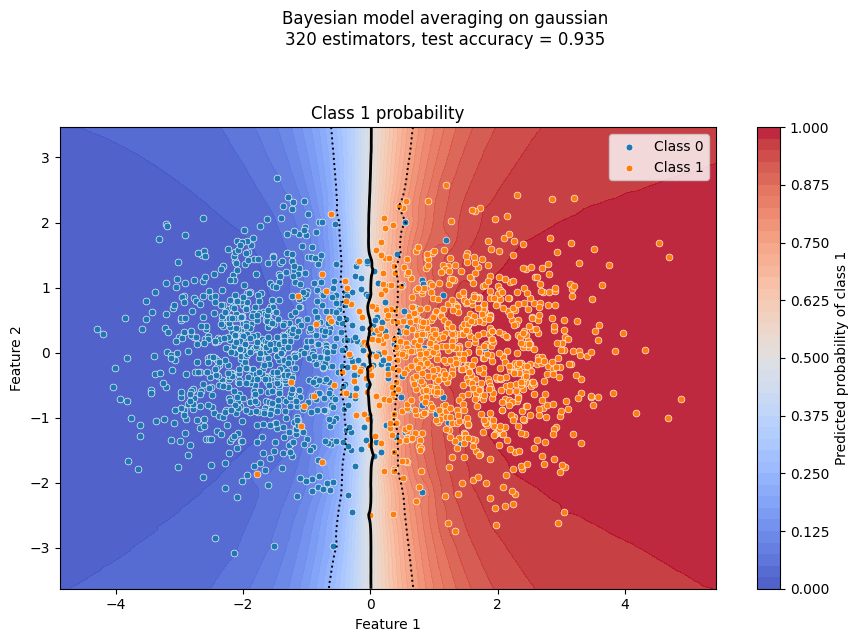

dataset: blobs
test accuracy: 0.840
estimators used: 500
converged: False
20 estimators: initial ensemble
40 estimators: median probability change = 0.003765
80 estimators: median probability change = 0.003508
160 estimators: median probability change = 0.003341
320 estimators: median probability change = 0.001565
500 estimators: median probability change = 0.001745


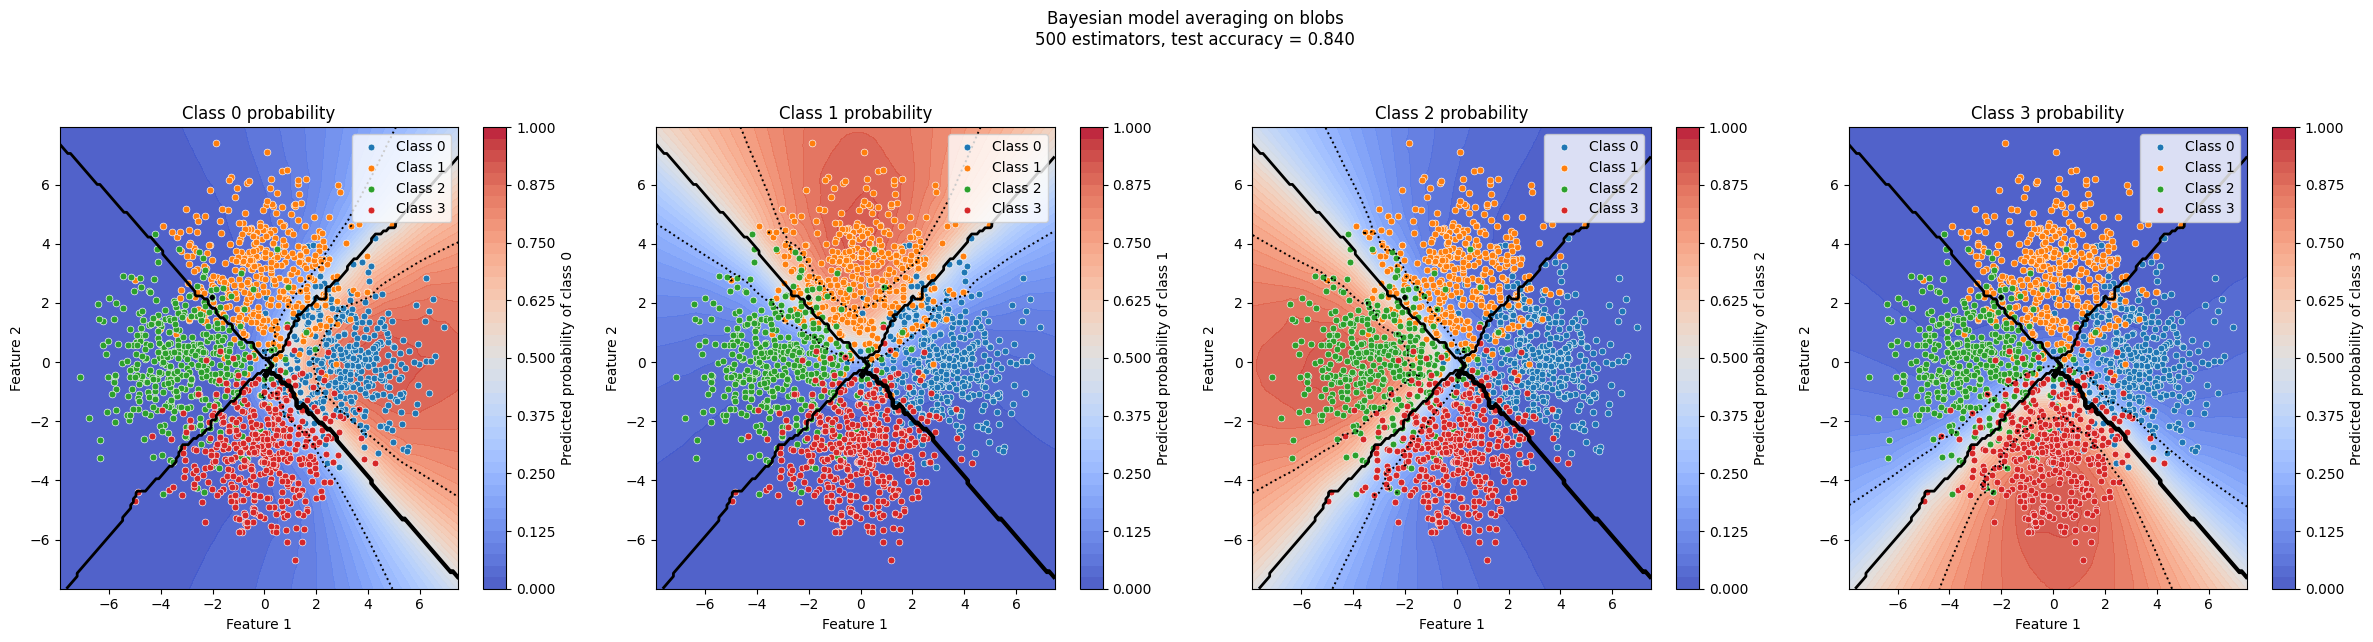

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

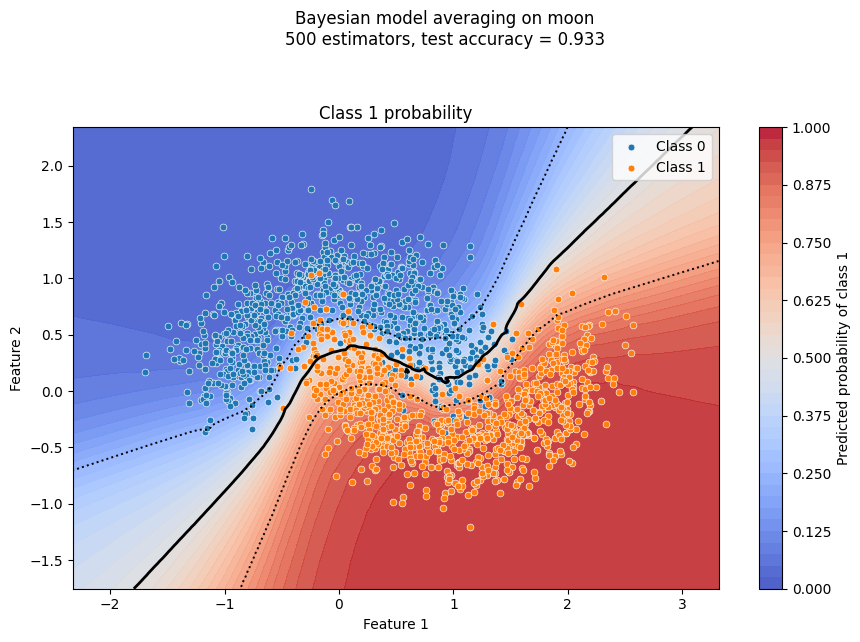

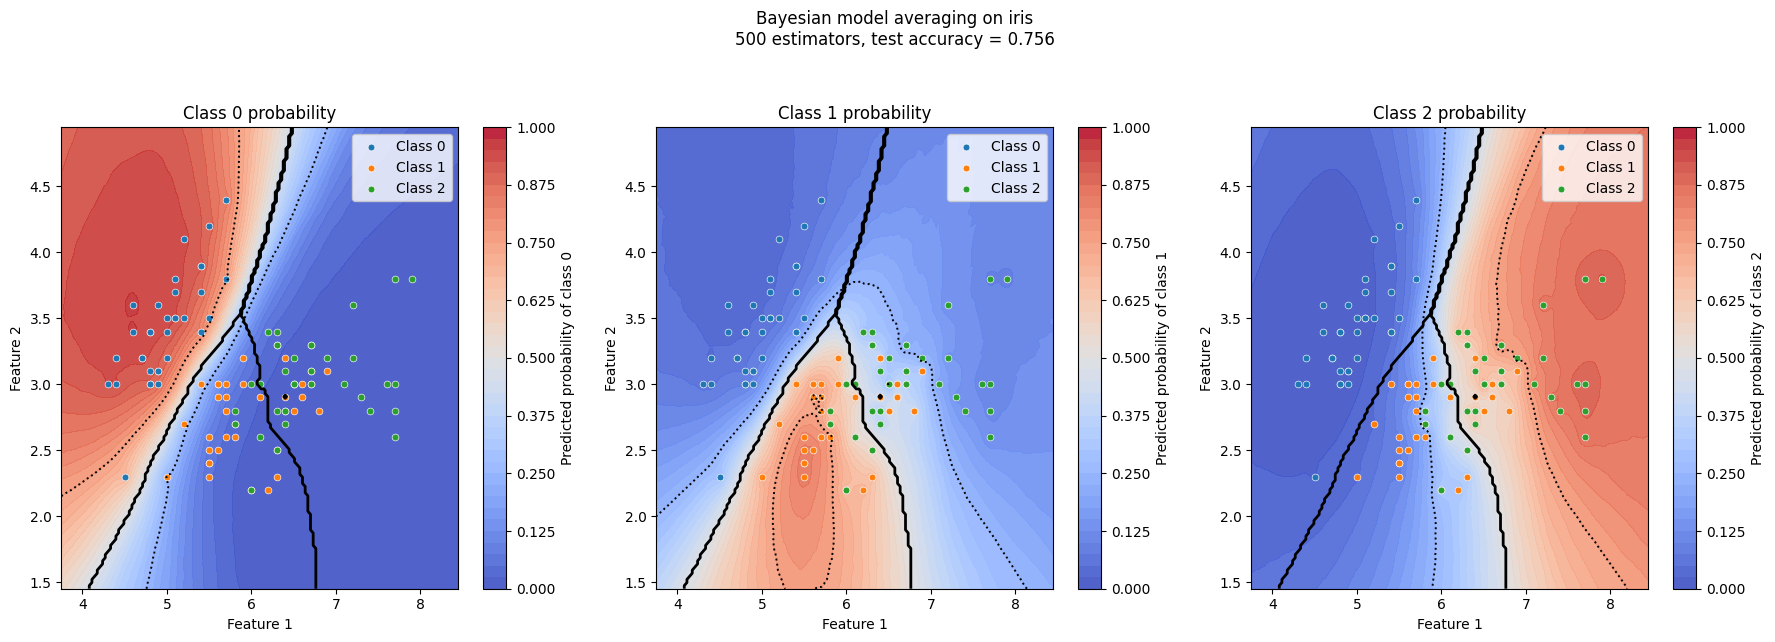

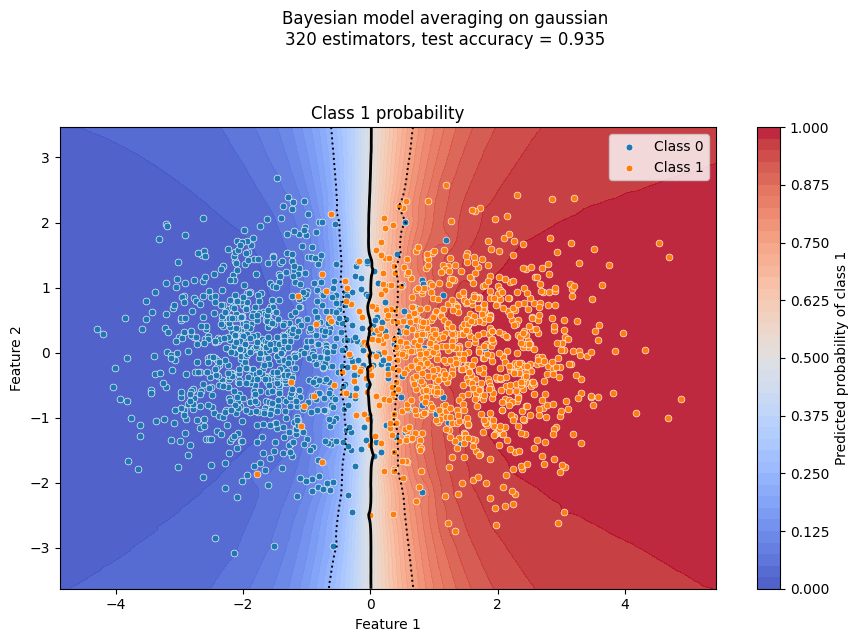

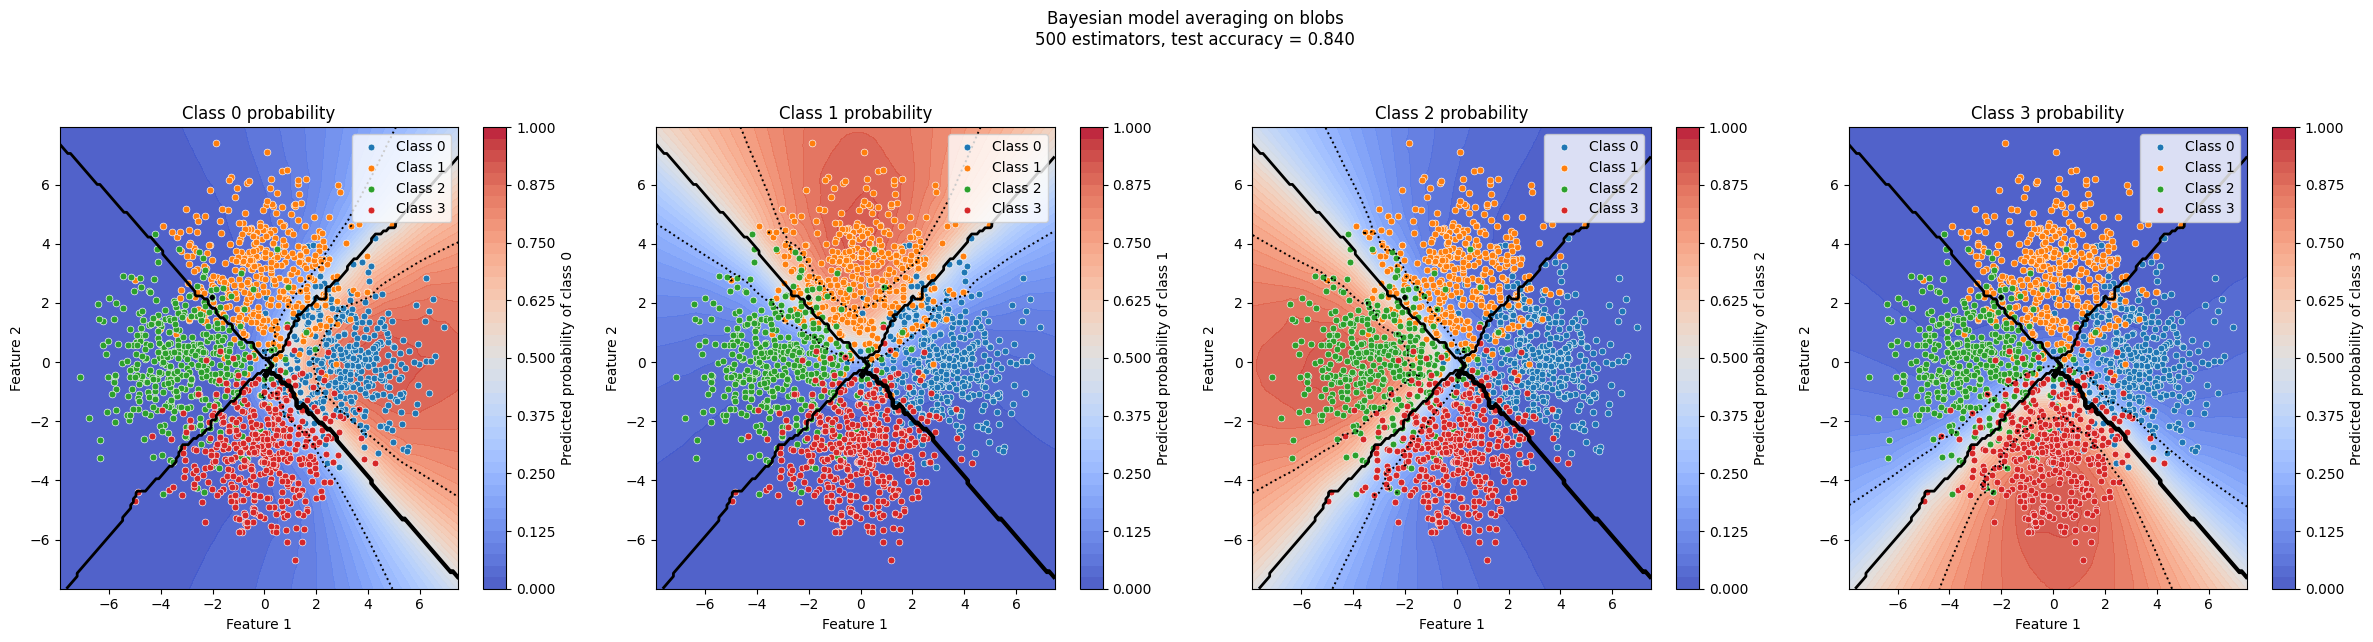

In [3]:
for dataset in DATASETS:
    result = run_2d_classification_experiment(
        dataset,
        dataset_parameters=DATA_PARAMETERS,
        **SPLIT_PARAMETERS,
        model_parameters=MODEL_PARAMETERS,
    )
    print(f"dataset: {result.dataset}")
    print(f"test accuracy: {result.test_accuracy:.3f}")
    print(f"estimators used: {result.model.n_estimators_}")
    print(f"converged: {result.model.converged_}")
    print(format_convergence_history(result))
    display(plot_probability_heatmap(result, **PLOT_PARAMETERS))